In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\global_earthquake_tsunami.csv")

In [4]:
df.head()

,date,latitude,longitude,magnitude,depth,tsunami
0,2001-01-13,23.5,121.0,7.7,33,0
1,2004-12-26,3.3,95.9,9.1,30,1
2,2010-02-27,-36.1,-72.9,8.8,35,1
3,2011-03-11,38.3,142.4,9.0,29,1
4,2015-04-25,28.2,84.7,7.8,15,0


In [5]:
df.tail()

,date,latitude,longitude,magnitude,depth,tsunami
3,2011-03-11,38.3,142.4,9.0,29,1
4,2015-04-25,28.2,84.7,7.8,15,0
5,2018-09-28,-0.2,119.8,7.5,20,1
6,2020-10-30,37.9,26.8,7.0,10,0
7,2022-06-22,33.0,69.0,6.1,45,0


In [7]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       8 non-null      object 
 1   latitude   8 non-null      float64
 2   longitude  8 non-null      float64
 3   magnitude  8 non-null      float64
 4   depth      8 non-null      int64  
 5   tsunami    8 non-null      int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 516.0+ bytes


In [8]:
df.describe()

,latitude,longitude,magnitude,depth,tsunami
count,8.000000,8.000000,8.00000,8.000000,8.000000
mean,15.987500,73.337500,7.87500,27.125000,0.500000
std,25.660221,69.084047,1.04983,11.457219,0.534522
min,-36.100000,-72.900000,6.10000,10.000000,0.000000
25%,2.425000,58.450000,7.37500,18.750000,0.000000
50%,25.850000,90.300000,7.75000,29.500000,0.500000
75%,34.225000,120.100000,8.85000,33.500000,1.000000
max,38.300000,142.400000,9.10000,45.000000,1.000000


In [9]:
#Data cleaning
df.isnull().sum()

date         0
latitude     0
longitude    0
magnitude    0
depth        0
tsunami      0
dtype: int64

In [14]:
#drop or fill nulls
df = df.dropna()
df.fillna(method='ffill',inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18584\695645954.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [15]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [27]:
#data type conversion
df['date'] = pd.to_datetime(df['date'])

In [21]:
df['year'] = df['date'].dt.year

In [22]:
yearly_counts = df['year'].value_counts().sort_index()

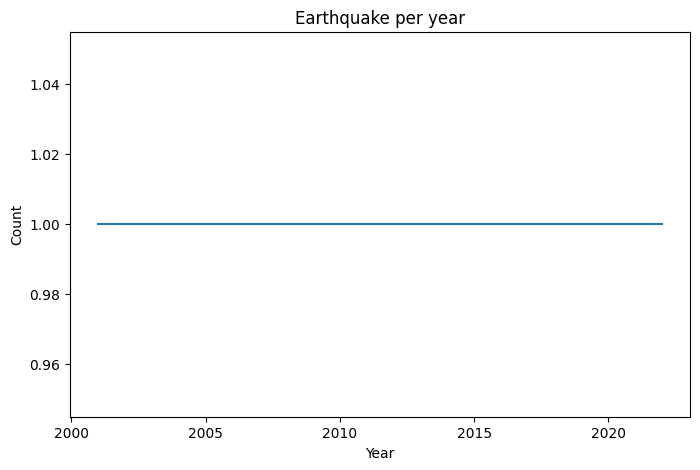

In [26]:
plt.figure(figsize=(8,5))
yearly_counts.plot()
plt.title("Earthquake per year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [29]:
df['tsunami'].value_counts()

tsunami
0    4
1    4
Name: count, dtype: int64

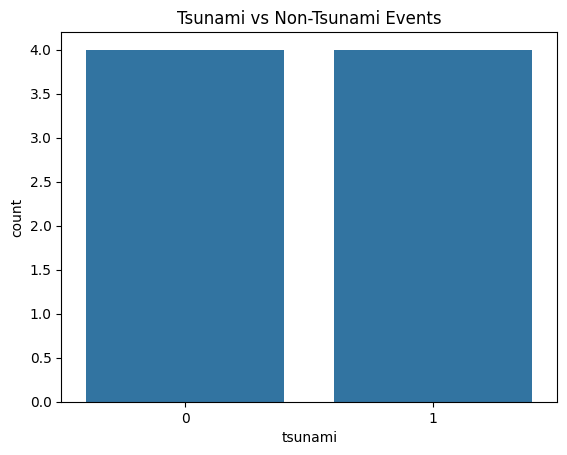

In [31]:
#Bar plot
sns.countplot(x='tsunami',data=df)
plt.title("Tsunami vs Non-Tsunami Events")
plt.show()

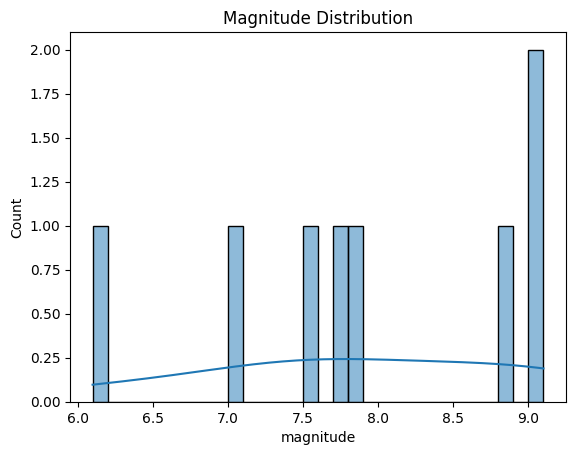

In [37]:
#magnitude analysis
sns.histplot(df['magnitude'],bins=30,kde=True)
plt.title("Magnitude Distribution")
plt.show()

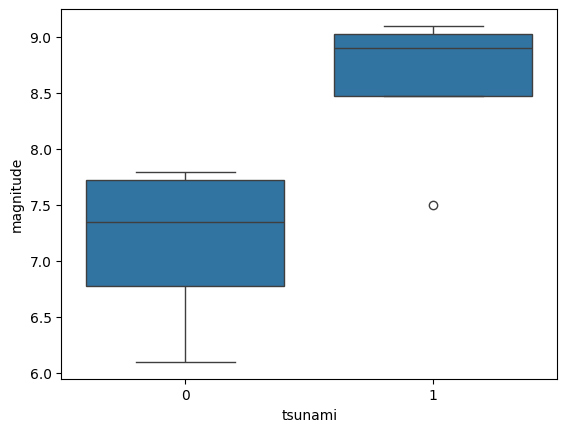

In [39]:
sns.boxplot(x='tsunami',y='magnitude',data=df)
plt.show()            

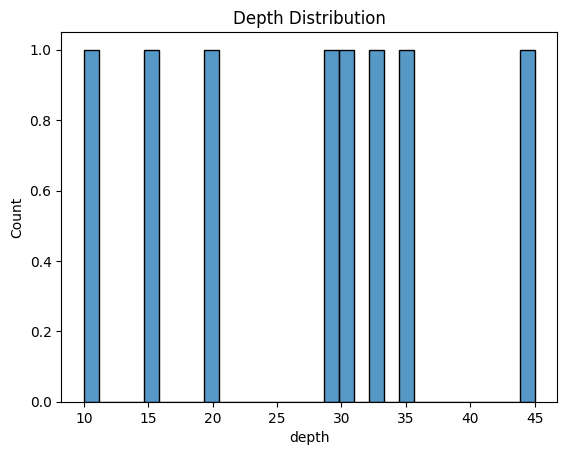

In [41]:
#depth analysis
sns.histplot(df['depth'],bins=30)
plt.title("Depth Distribution")
plt.show()

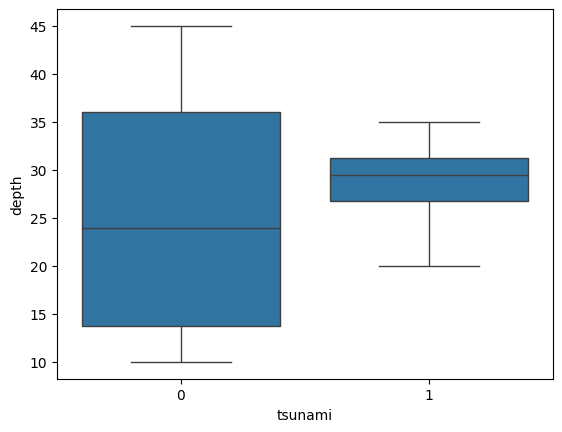

In [42]:
sns.boxplot(x='tsunami',y='depth',data=df)
plt.show()

In [44]:
major_eq = df[df['magnitude']>= 8.0]
major_eq

,date,latitude,longitude,magnitude,depth,tsunami,year
1,2004-12-26,3.3,95.9,9.1,30,1,2004
2,2010-02-27,-36.1,-72.9,8.8,35,1,2010
3,2011-03-11,38.3,142.4,9.0,29,1,2011


In [45]:
len(major_eq)

3

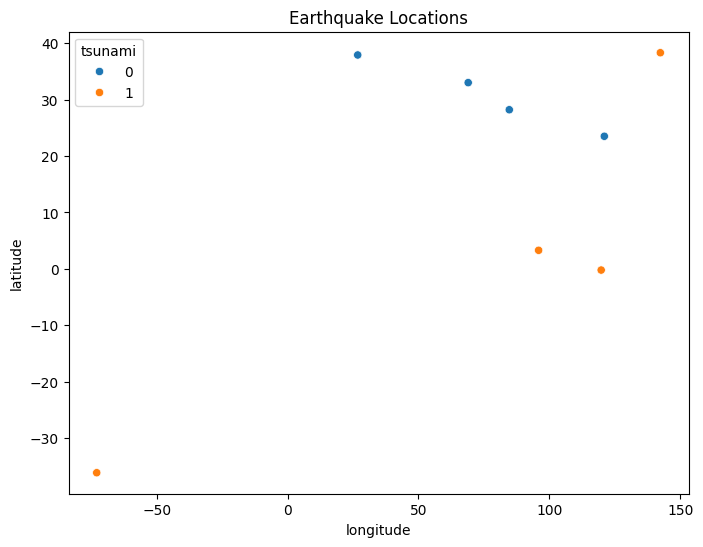

In [48]:
#geographic analysis
plt.figure(figsize=(8,6))
sns.scatterplot(x='longitude',y='latitude',hue='tsunami',data=df)
plt.title("Earthquake Locations")
plt.show()

In [52]:
#corrrelation analysis:
corr = df.corr(numeric_only=True)

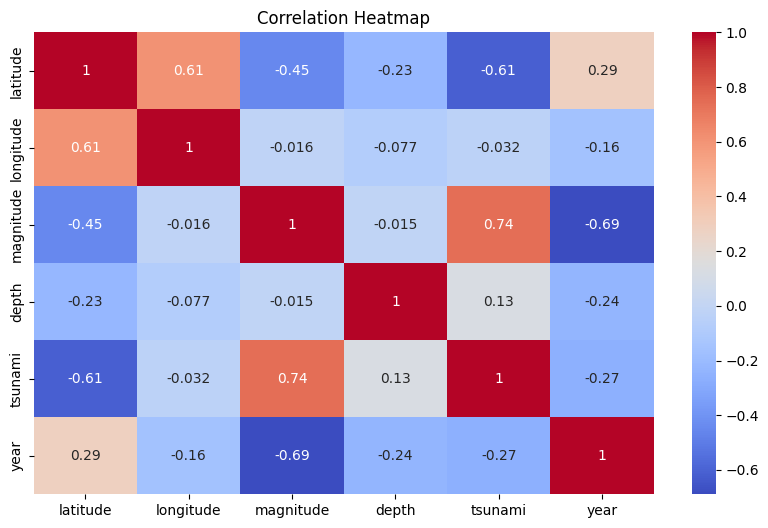

In [51]:
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [54]:
#Group analysis:average magnitude
df.groupby('tsunami')['magnitude'].mean()

tsunami
0    7.15
1    8.60
Name: magnitude, dtype: float64

In [55]:
#average depth:
df.groupby('tsunami')['depth'].mean()

tsunami
0    25.75
1    28.50
Name: depth, dtype: float64

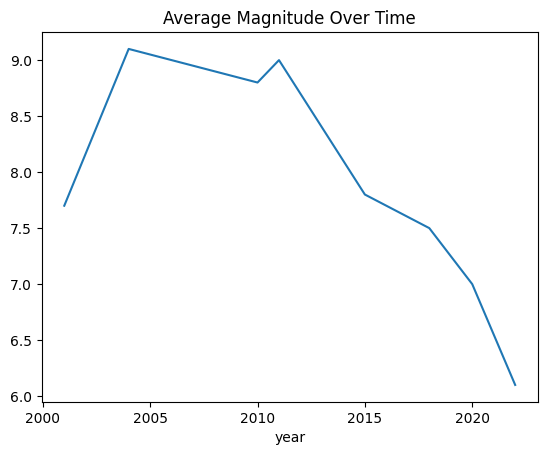

In [56]:
#trend analysis
df.groupby('year')['magnitude'].mean().plot()
plt.title("Average Magnitude Over Time")
plt.show()